# Chorus: Comprehensive Oracle Showcase

This notebook demonstrates **all 6 oracles** available in Chorus, covering every major operation:

| Oracle | Framework | Input Window | Resolution | Tracks |
|--------|-----------|-------------|------------|--------|
| **Enformer** | TensorFlow | 393 kb | 128 bp | 5,313 (DNASE, CAGE, CHIP, ATAC) |
| **Borzoi** | PyTorch | 524 kb | 32 bp | 7,611 (DNASE, CAGE, CHIP, ATAC, RNA) |
| **ChromBPNet** | TensorFlow | 2 kb | 1 bp | Per-model (DNASE, ATAC) |
| **Sei** | PyTorch | 4 kb | 128 bp | 21,907 (histone marks, TF binding, sequence classes) |
| **LegNet** | PyTorch | 230 bp | 1 bp | 1 (LentiMPRA) |
| **AlphaGenome** | JAX | 1 Mb | 1 bp | 5,930 (DNASE, CAGE, CHIP, ATAC, RNA, splice sites) |

**Operations demonstrated:**
1. Wild-type prediction (`predict`)
2. Region replacement (`predict_region_replacement`)
3. Sequence insertion (`predict_region_insertion_at`)
4. Variant effect analysis (`predict_variant_effect`)
5. Sub-region scoring (`score_region`)
6. Focused variant effect scoring (`score_variant_effect`)
7. Gene expression analysis (`analyze_gene_expression`)
8. Variant effect on gene expression (`analyze_variant_effect_on_gene`)
9. Cross-oracle comparison visualization

**Target region:** GATA1 TSS on chrX (a well-studied erythroid transcription factor)

## Setup and Imports

In [1]:
import chorus
from chorus.utils import get_genome, extract_sequence
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['figure.dpi'] = 120

# Reference genome
genome_path = get_genome('hg38')
print(f"Reference genome: {genome_path}")

# GATA1 TSS region — used across all oracles
GATA1_REGION = "chrX:48777634-48790694"
GATA1_CHROM, GATA1_START, GATA1_END = "chrX", 48777634, 48790694
PLOT_RANGE = "chrX:48726820-48841508"

wt_seq = extract_sequence(GATA1_REGION, str(genome_path))
print(f"\nGATA1 region: {GATA1_REGION} ({len(wt_seq):,} bp, GC={100*(wt_seq.count('G')+wt_seq.count('C'))/len(wt_seq):.1f}%)")

Reference genome: /Users/lp698/chorus/genomes/hg38.fa

GATA1 region: chrX:48777634-48790694 (13,061 bp, GC=47.2%)


In [2]:
from coolbox.api import *

# Helper: load an oracle, predict on GATA1 region, and return results
def load_and_predict(oracle_name, track_ids, **kwargs):
    """Load oracle, make GATA1 prediction, return (oracle, results)."""
    print(f"\n{'='*60}")
    print(f"  {oracle_name.upper()}")
    print(f"{'='*60}")
    oracle = chorus.create_oracle(
        oracle_name,
        use_environment=True,
        reference_fasta=str(genome_path),
        **kwargs
    )
    oracle.load_pretrained_model()
    print(f"  Loaded. Making prediction with {len(track_ids)} tracks...")
    results = oracle.predict(
        (GATA1_CHROM, GATA1_START, GATA1_END),
        track_ids
    )
    for tid, track in results.items():
        print(f"    {tid}: shape={track.values.shape}, mean={np.mean(track.values):.4f}, max={np.max(track.values):.4f}")
    return oracle, results

---
## 1. Enformer — TensorFlow, 393 kb context, 128 bp bins

Enformer (DeepMind, 2021) predicts 5,313 human genomic tracks from 393 kb of DNA sequence. It uses a transformer architecture with attention layers that capture long-range regulatory interactions.

In [3]:
# Enformer: DNASE and CAGE tracks for K562
enformer_tracks = ['ENCFF413AHU', 'CNhs11250']  # DNASE:K562, CAGE:K562
enformer_oracle, enformer_results = load_and_predict('enformer', enformer_tracks)

2026-03-13 07:43:06,324 - chorus.core.base - INFO - Device: auto-detect (GPU if available, else CPU)


2026-03-13 07:43:06,336 - chorus.core.environment.manager - INFO - Found conda via CONDA_EXE: /Users/lp698/miniforge3/bin/conda


2026-03-13 07:43:06,336 - chorus.core.environment.manager - INFO - Found mamba at: /Users/lp698/miniforge3/bin/mamba


2026-03-13 07:43:06,336 - chorus.core.platform - INFO - Detected platform: Darwin arm64 (key=macos_arm64, cuda=False)



  ENFORMER


...

2026-03-13 07:43:11,439 - chorus.oracles.enformer - INFO - Loading Enformer model from https://tfhub.dev/deepmind/enformer/1...


2026-03-13 07:43:15,842 - chorus.oracles.enformer - INFO - Enformer model loaded successfully in environment!


  Loaded. Making prediction with 2 tracks...


2026-03-13 07:43:36,811 - chorus.oracles.enformer_source.enformer_metadata - INFO - Loaded 5313 track metadata entries


    ENCFF413AHU: shape=(896,), mean=0.4842, max=22.4620
    CNhs11250: shape=(896,), mean=0.5957, max=120.8119


[ERROR:tab.py:549 - get_indexed_tab_reader()] bgzip is not installed.


2026-03-13 07:43:36,826 - coolbox.utilities.reader.tab - ERROR - bgzip is not installed.


[WARNING:tab.py:550 - get_indexed_tab_reader()] Try to use TabFileReaderInMemory instead


2026-03-13 07:43:36,826 - coolbox.utilities.reader.tab - WARNING - Try to use TabFileReaderInMemory instead


[ERROR:tab.py:549 - get_indexed_tab_reader()] bgzip is not installed.


2026-03-13 07:43:36,837 - coolbox.utilities.reader.tab - ERROR - bgzip is not installed.


[WARNING:tab.py:550 - get_indexed_tab_reader()] Try to use TabFileReaderInMemory instead


2026-03-13 07:43:36,837 - coolbox.utilities.reader.tab - WARNING - Try to use TabFileReaderInMemory instead


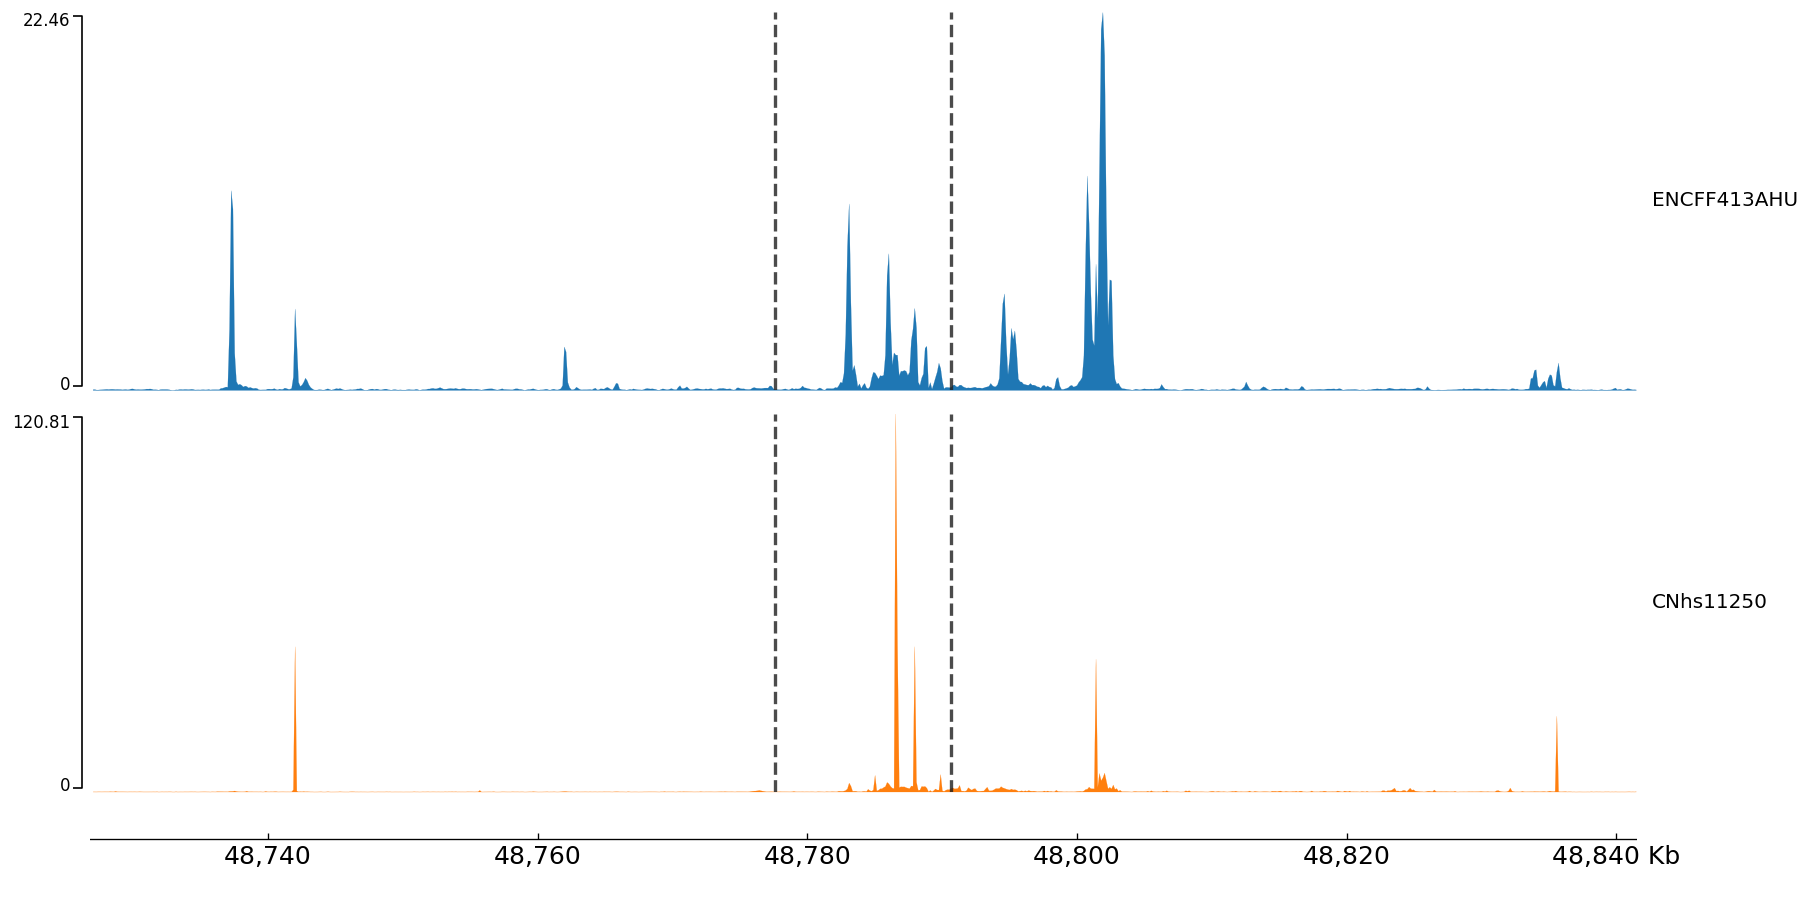

In [4]:
# Visualize Enformer predictions
preds = list(enformer_results.values())
frame = preds[0].get_coolbox_representation(add_xaxis=(len(preds) == 1))
for p in preds[1:]:
    frame = frame + Spacer(0.5) + p.get_coolbox_representation(add_xaxis=(p is preds[-1]))
frame.plot(PLOT_RANGE)

---
## 2. Borzoi — PyTorch, 524 kb context, 32 bp bins

Borzoi (Calico, 2023) uses a longer context window (524 kb) and finer resolution (32 bp bins) than Enformer. It predicts 7,611 tracks and uses a U-net-style architecture.

In [5]:
# Borzoi: DNASE and CAGE tracks for K562
# Use Borzoi metadata to find track IDs
borzoi_oracle_tmp = chorus.create_oracle('borzoi', use_environment=False)
borzoi_dnase = borzoi_oracle_tmp.get_track_info("DNASE:K562")
borzoi_cage = borzoi_oracle_tmp.get_track_info("CAGE:K562")
print("Borzoi DNASE:K562 tracks:", len(borzoi_dnase))
print("Borzoi CAGE:K562 tracks:", len(borzoi_cage))
if len(borzoi_dnase) > 0:
    print(f"  First DNASE: {borzoi_dnase.iloc[0]['identifier']}")
if len(borzoi_cage) > 0:
    print(f"  First CAGE: {borzoi_cage.iloc[0]['identifier']}")

# Pick first available tracks
borzoi_track_ids = []
if len(borzoi_dnase) > 0:
    borzoi_track_ids.append(borzoi_dnase.iloc[0]['identifier'])
if len(borzoi_cage) > 0:
    borzoi_track_ids.append(borzoi_cage.iloc[0]['identifier'])
print(f"\nUsing tracks: {borzoi_track_ids}")

2026-03-13 07:43:36,925 - chorus.core.base - INFO - Device: auto-detect (GPU if available, else CPU)


2026-03-13 07:43:36,925 - chorus.core.environment.manager - INFO - Found conda via CONDA_EXE: /Users/lp698/miniforge3/bin/conda


2026-03-13 07:43:36,926 - chorus.core.environment.manager - INFO - Found mamba at: /Users/lp698/miniforge3/bin/mamba


2026-03-13 07:43:36,926 - chorus.core.platform - INFO - Detected platform: Darwin arm64 (key=macos_arm64, cuda=False)


2026-03-13 07:43:38,349 - chorus.core.base - INFO - Using conda environment: chorus-borzoi


2026-03-13 07:43:38,443 - chorus.oracles.borzoi_source.borzoi_metadata - INFO - Created mapping for 7611 track identifiers


2026-03-13 07:43:38,443 - chorus.oracles.borzoi_source.borzoi_metadata - INFO - First few identifiers: ['CNhs10608+', 'CNhs10608-', 'CNhs10610+', 'CNhs10610-', 'CNhs10612+']


Borzoi DNASE:K562 tracks: 7
Borzoi CAGE:K562 tracks: 0
  First DNASE: ENCFF899YDP

Using tracks: ['ENCFF899YDP']


In [6]:
borzoi_oracle, borzoi_results = load_and_predict('borzoi', borzoi_track_ids)

2026-03-13 07:43:38,804 - chorus.core.base - INFO - Device: auto-detect (GPU if available, else CPU)


2026-03-13 07:43:38,805 - chorus.core.environment.manager - INFO - Found conda via CONDA_EXE: /Users/lp698/miniforge3/bin/conda


2026-03-13 07:43:38,805 - chorus.core.environment.manager - INFO - Found mamba at: /Users/lp698/miniforge3/bin/mamba


2026-03-13 07:43:38,805 - chorus.core.platform - INFO - Detected platform: Darwin arm64 (key=macos_arm64, cuda=False)



  BORZOI


2026-03-13 07:43:40,229 - chorus.core.base - INFO - Using conda environment: chorus-borzoi


2026-03-13 07:43:40,230 - chorus.oracles.borzoi - INFO - Loading Borzoi model fold 0


2026-03-13 07:43:44,229 - chorus.oracles.borzoi - INFO - Borzoi model loaded successfully in environment!


  Loaded. Making prediction with 1 tracks...


    ENCFF899YDP: shape=(6144,), mean=0.2435, max=7.0530


[ERROR:tab.py:549 - get_indexed_tab_reader()] bgzip is not installed.


2026-03-13 07:44:00,083 - coolbox.utilities.reader.tab - ERROR - bgzip is not installed.


[WARNING:tab.py:550 - get_indexed_tab_reader()] Try to use TabFileReaderInMemory instead


2026-03-13 07:44:00,084 - coolbox.utilities.reader.tab - WARNING - Try to use TabFileReaderInMemory instead


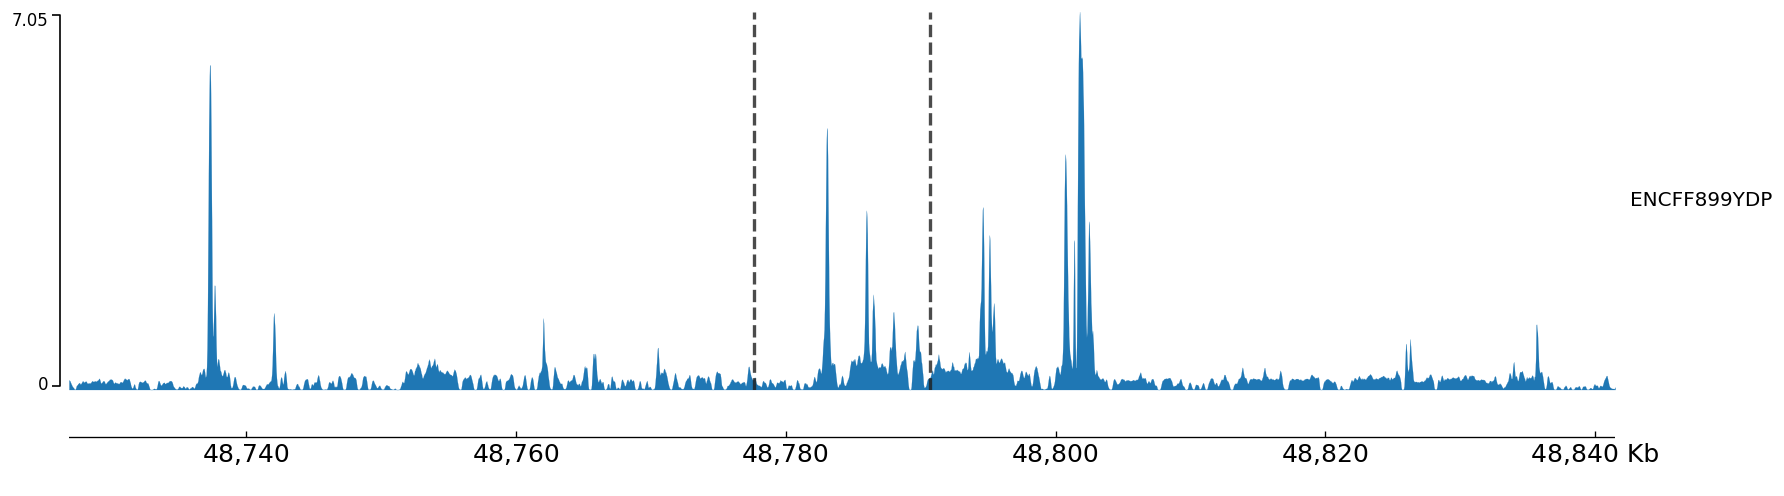

In [7]:
# Visualize Borzoi predictions — note the finer 32bp resolution
preds = list(borzoi_results.values())
frame = preds[0].get_coolbox_representation(add_xaxis=(len(preds) == 1))
for p in preds[1:]:
    frame = frame + Spacer(0.5) + p.get_coolbox_representation(add_xaxis=(p is preds[-1]))
frame.plot(PLOT_RANGE)

---
## 3. ChromBPNet — TensorFlow, base-pair resolution DNASE

ChromBPNet predicts chromatin accessibility (DNASE/ATAC) at single base-pair resolution from short input windows. It is trained per cell type.

In [8]:
# ChromBPNet: DNASE for HepG2 (cell-type specific model)
chrombpnet_tracks = ['DNASE:HepG2']

print(f"\n{'='*60}")
print(f"  CHROMBPNET")
print(f"{'='*60}")
chrombpnet_oracle = chorus.create_oracle(
    'chrombpnet',
    use_environment=True,
    reference_fasta=str(genome_path)
)
chrombpnet_oracle.load_pretrained_model(assay='DNASE', cell_type='HepG2', fold=0)
print(f"  Loaded. Making prediction with {len(chrombpnet_tracks)} tracks...")
chrombpnet_results = chrombpnet_oracle.predict(
    (GATA1_CHROM, GATA1_START, GATA1_END),
    chrombpnet_tracks
)
for tid, track in chrombpnet_results.items():
    print(f"    {tid}: shape={track.values.shape}, mean={np.mean(track.values):.4f}, max={np.max(track.values):.4f}")

2026-03-13 07:44:00,172 - chorus.core.base - INFO - Device: auto-detect (GPU if available, else CPU)


2026-03-13 07:44:00,173 - chorus.core.environment.manager - INFO - Found conda via CONDA_EXE: /Users/lp698/miniforge3/bin/conda


2026-03-13 07:44:00,173 - chorus.core.environment.manager - INFO - Found mamba at: /Users/lp698/miniforge3/bin/mamba


2026-03-13 07:44:00,173 - chorus.core.platform - INFO - Detected platform: Darwin arm64 (key=macos_arm64, cuda=False)



  CHROMBPNET


...

2026-03-13 07:44:02,666 - chorus.oracles.chrombpnet - INFO - Loading ChromBPNet model...


Loading in environment


2026-03-13 07:44:06,613 - chorus.oracles.chrombpnet - INFO - ChromBPNet model loaded successfully in environment!


  Loaded. Making prediction with 1 tracks...


    DNASE:HepG2: shape=(13060,), mean=0.1345, max=2.5971


[ERROR:tab.py:549 - get_indexed_tab_reader()] bgzip is not installed.


2026-03-13 07:44:11,264 - coolbox.utilities.reader.tab - ERROR - bgzip is not installed.


[WARNING:tab.py:550 - get_indexed_tab_reader()] Try to use TabFileReaderInMemory instead


2026-03-13 07:44:11,264 - coolbox.utilities.reader.tab - WARNING - Try to use TabFileReaderInMemory instead


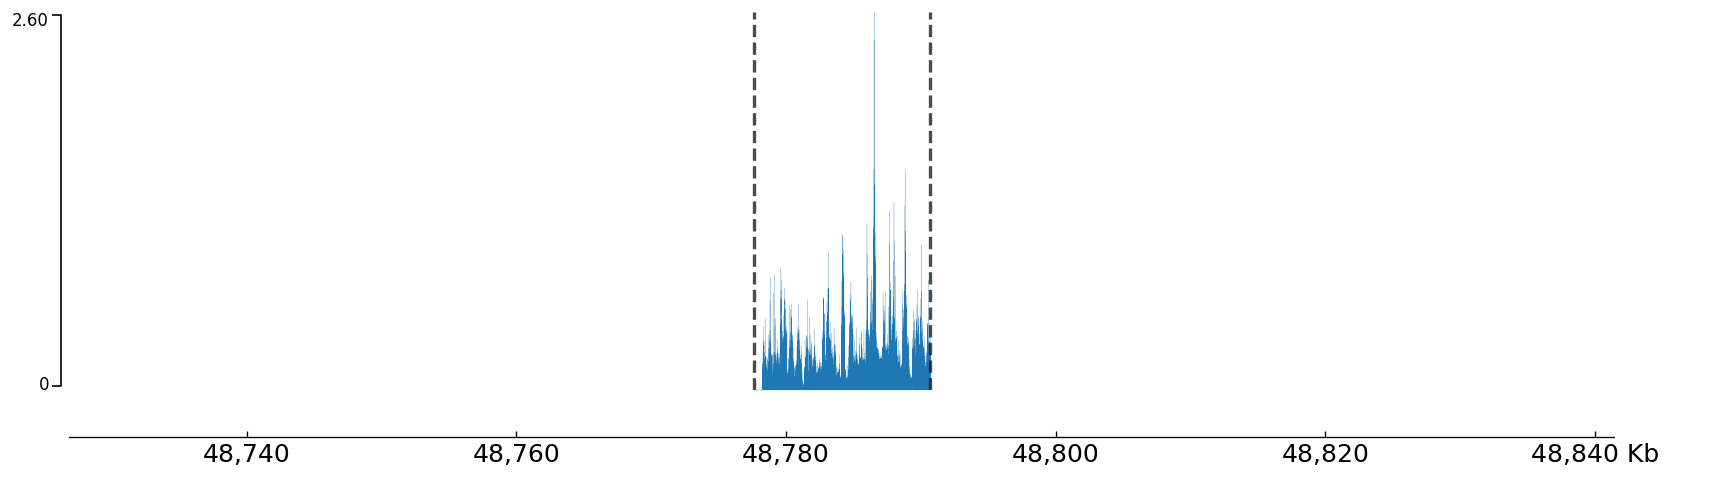

In [9]:
# Visualize ChromBPNet — base-pair resolution signal
preds = list(chrombpnet_results.values())
frame = preds[0].get_coolbox_representation()
frame.plot(PLOT_RANGE)

---
## 4. Sei — PyTorch, sequence class predictions

Sei (Chen et al., 2022) predicts 21,907 chromatin profiles and 40 sequence classes. It classifies genomic regions into functional categories (enhancer, promoter, CTCF binding, etc.).

In [10]:
# Sei: select sequence classes and histone mark targets
sei_oracle = chorus.create_oracle(
    'sei', 
    sliding_predict=True,
    use_environment=True,
    reference_fasta=str(genome_path)
)
sei_oracle.load_pretrained_model()

# Select promoter and enhancer classes + H3K4me3 targets
sei_classes = sei_oracle.select_classes(pats=[[None, 'Promoter'], [None, 'Enhancer']])
sei_targets = sei_oracle.select_targets(pats=[['H3K4me3', 'K562']])

print(f"Selected {len(sei_classes)} sequence classes:")
for c in sei_classes[:5]:
    print(f"  {c}")
print(f"  ... and {len(sei_classes)-5} more")
print(f"\nSelected {len(sei_targets)} H3K4me3 targets for K562")

2026-03-13 07:44:11,321 - chorus.core.base - INFO - Device: auto-detect (GPU if available, else CPU)


2026-03-13 07:44:11,321 - chorus.core.environment.manager - INFO - Found conda via CONDA_EXE: /Users/lp698/miniforge3/bin/conda


2026-03-13 07:44:11,322 - chorus.core.environment.manager - INFO - Found mamba at: /Users/lp698/miniforge3/bin/mamba


2026-03-13 07:44:11,322 - chorus.core.platform - INFO - Detected platform: Darwin arm64 (key=macos_arm64, cuda=False)


2026-03-13 07:44:12,993 - chorus.core.base - INFO - Using conda environment: chorus-sei


2026-03-13 07:44:19,510 - chorus.oracles.sei - INFO - Sei model loaded successfully in environment!


Selected 13 sequence classes:
  CA#E1@Stem cell@Enhancer@5
  CA#E2@Multi-tissue@Enhancer@6
  CA#E3@Brain / Melanocyte@Enhancer@7
  CA#E4@Multi-tissue@Enhancer@9
  CA#E5@B-cell-like@Enhancer@12
  ... and 8 more

Selected 92 H3K4me3 targets for K562


In [11]:
# Predict with Sei — mix of sequence classes and histone targets
sei_track_ids = sei_classes[:2] + sei_targets[:2]
print(f"Predicting with tracks: {sei_track_ids}")

sei_results = sei_oracle.predict(
    (GATA1_CHROM, GATA1_START, GATA1_END),
    sei_track_ids
)

for tid, track in sei_results.items():
    print(f"  {tid[:60]}: shape={track.values.shape}, max={np.max(track.values):.4f}")

Predicting with tracks: ['CA#E1@Stem cell@Enhancer@5', 'CA#E2@Multi-tissue@Enhancer@6', 'TA#K562_Erythroblast_Bone_Marrow@H3K4me3@ID:2034', 'TA#K562_Erythroblast_Bone_Marrow@H3K4me3@ID:2035']


2026-03-13 07:44:48,307 - chorus.core.result - WARNING - Unknown implementation 'Stem cell'. Available: ATAC, CAGE, CHIP, DNASE, LentiMPRA, PRO_CAP, RNA, SPLICE_SITES


2026-03-13 07:44:48,308 - chorus.core.result - WARNING - Unknown implementation 'Multi-tissue'. Available: ATAC, CAGE, CHIP, DNASE, LentiMPRA, PRO_CAP, RNA, SPLICE_SITES


2026-03-13 07:44:48,308 - chorus.core.result - WARNING - Unknown implementation 'H3K4me3'. Available: ATAC, CAGE, CHIP, DNASE, LentiMPRA, PRO_CAP, RNA, SPLICE_SITES


2026-03-13 07:44:48,309 - chorus.core.result - WARNING - Unknown implementation 'H3K4me3'. Available: ATAC, CAGE, CHIP, DNASE, LentiMPRA, PRO_CAP, RNA, SPLICE_SITES


  CA#E1@Stem cell@Enhancer@5: shape=(103,), max=2.7630
  CA#E2@Multi-tissue@Enhancer@6: shape=(103,), max=2.1708
  TA#K562_Erythroblast_Bone_Marrow@H3K4me3@ID:2034: shape=(103,), max=0.2457
  TA#K562_Erythroblast_Bone_Marrow@H3K4me3@ID:2035: shape=(103,), max=0.3531


[ERROR:tab.py:549 - get_indexed_tab_reader()] bgzip is not installed.


2026-03-13 07:44:48,321 - coolbox.utilities.reader.tab - ERROR - bgzip is not installed.


[WARNING:tab.py:550 - get_indexed_tab_reader()] Try to use TabFileReaderInMemory instead


2026-03-13 07:44:48,322 - coolbox.utilities.reader.tab - WARNING - Try to use TabFileReaderInMemory instead


[ERROR:tab.py:549 - get_indexed_tab_reader()] bgzip is not installed.


...

2026-03-13 07:44:48,342 - coolbox.utilities.reader.tab - WARNING - Try to use TabFileReaderInMemory instead


[ERROR:tab.py:549 - get_indexed_tab_reader()] bgzip is not installed.


2026-03-13 07:44:48,350 - coolbox.utilities.reader.tab - ERROR - bgzip is not installed.


[WARNING:tab.py:550 - get_indexed_tab_reader()] Try to use TabFileReaderInMemory instead


2026-03-13 07:44:48,351 - coolbox.utilities.reader.tab - WARNING - Try to use TabFileReaderInMemory instead


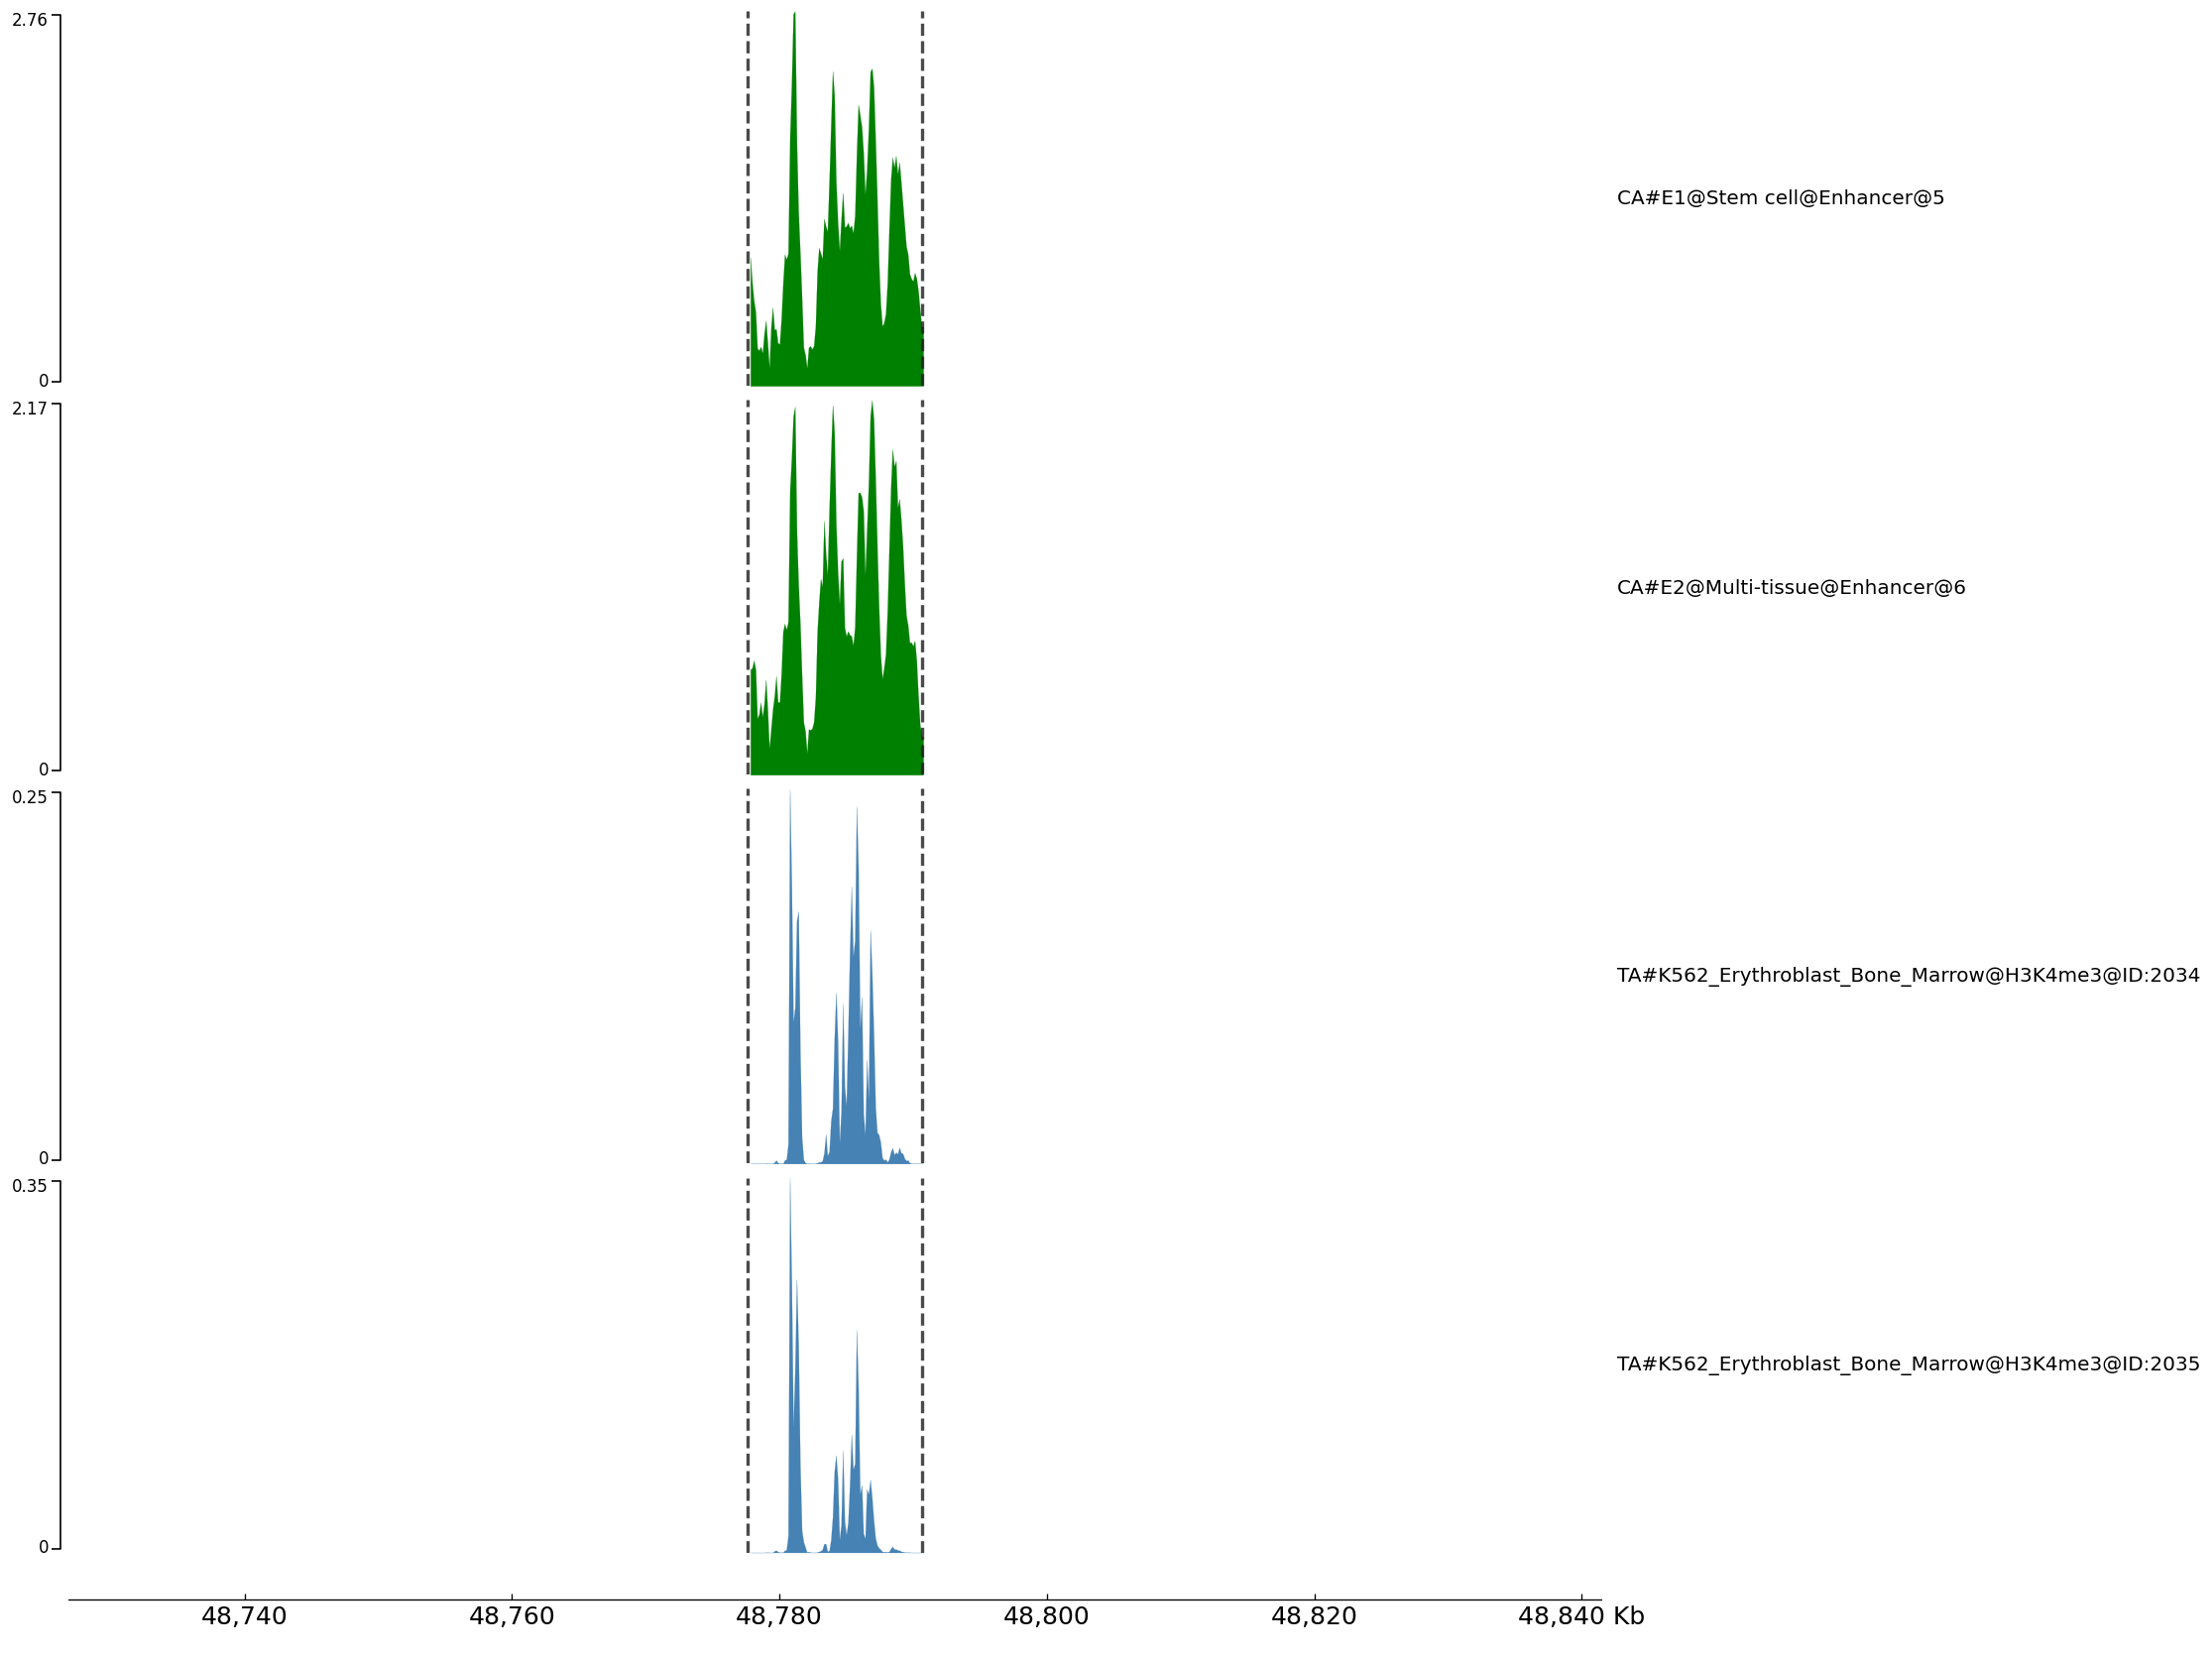

In [12]:
# Visualize Sei predictions — sequence classes and histone marks
sei_colors = {'class': 'green', 'target': 'steelblue'}
preds = list(sei_results.values())
frame = preds[0].get_coolbox_representation(add_xaxis=(len(preds) == 1), override_params={'color': 'green'})
for i, p in enumerate(preds[1:], 1):
    color = 'green' if i < len(sei_classes[:2]) else 'steelblue'
    is_last = (p is preds[-1])
    frame = frame + Spacer(0.3) + p.get_coolbox_representation(add_xaxis=is_last, override_params={'color': color})
frame.plot(PLOT_RANGE)

---
## 5. LegNet — PyTorch, LentiMPRA predictions

LegNet predicts Lentiviral MPRA (Massively Parallel Reporter Assay) activity from 230 bp sequences. It measures regulatory element activity as a continuous score.

In [13]:
# LegNet: LentiMPRA activity for HepG2
legnet_tracks = ['LentiMPRA:HepG2']
legnet_oracle, legnet_results = load_and_predict('legnet', legnet_tracks)

2026-03-13 07:44:48,490 - chorus.core.base - INFO - Device: auto-detect (GPU if available, else CPU)


2026-03-13 07:44:48,491 - chorus.core.environment.manager - INFO - Found conda via CONDA_EXE: /Users/lp698/miniforge3/bin/conda


2026-03-13 07:44:48,491 - chorus.core.environment.manager - INFO - Found mamba at: /Users/lp698/miniforge3/bin/mamba


2026-03-13 07:44:48,491 - chorus.core.platform - INFO - Detected platform: Darwin arm64 (key=macos_arm64, cuda=False)



  LEGNET


2026-03-13 07:44:49,700 - chorus.core.base - INFO - Using conda environment: chorus-legnet


2026-03-13 07:44:52,689 - chorus.oracles.legnet - INFO - LegNet model loaded successfully in environment!


  Loaded. Making prediction with 1 tracks...


    LentiMPRA:HepG2: shape=(262,), mean=-0.7341, max=0.9833


[ERROR:tab.py:549 - get_indexed_tab_reader()] bgzip is not installed.


2026-03-13 07:45:35,335 - coolbox.utilities.reader.tab - ERROR - bgzip is not installed.


[WARNING:tab.py:550 - get_indexed_tab_reader()] Try to use TabFileReaderInMemory instead


2026-03-13 07:45:35,336 - coolbox.utilities.reader.tab - WARNING - Try to use TabFileReaderInMemory instead


[ERROR:tab.py:549 - get_indexed_tab_reader()] bgzip is not installed.


2026-03-13 07:45:35,346 - coolbox.utilities.reader.tab - ERROR - bgzip is not installed.


[WARNING:tab.py:550 - get_indexed_tab_reader()] Try to use TabFileReaderInMemory instead


2026-03-13 07:45:35,346 - coolbox.utilities.reader.tab - WARNING - Try to use TabFileReaderInMemory instead


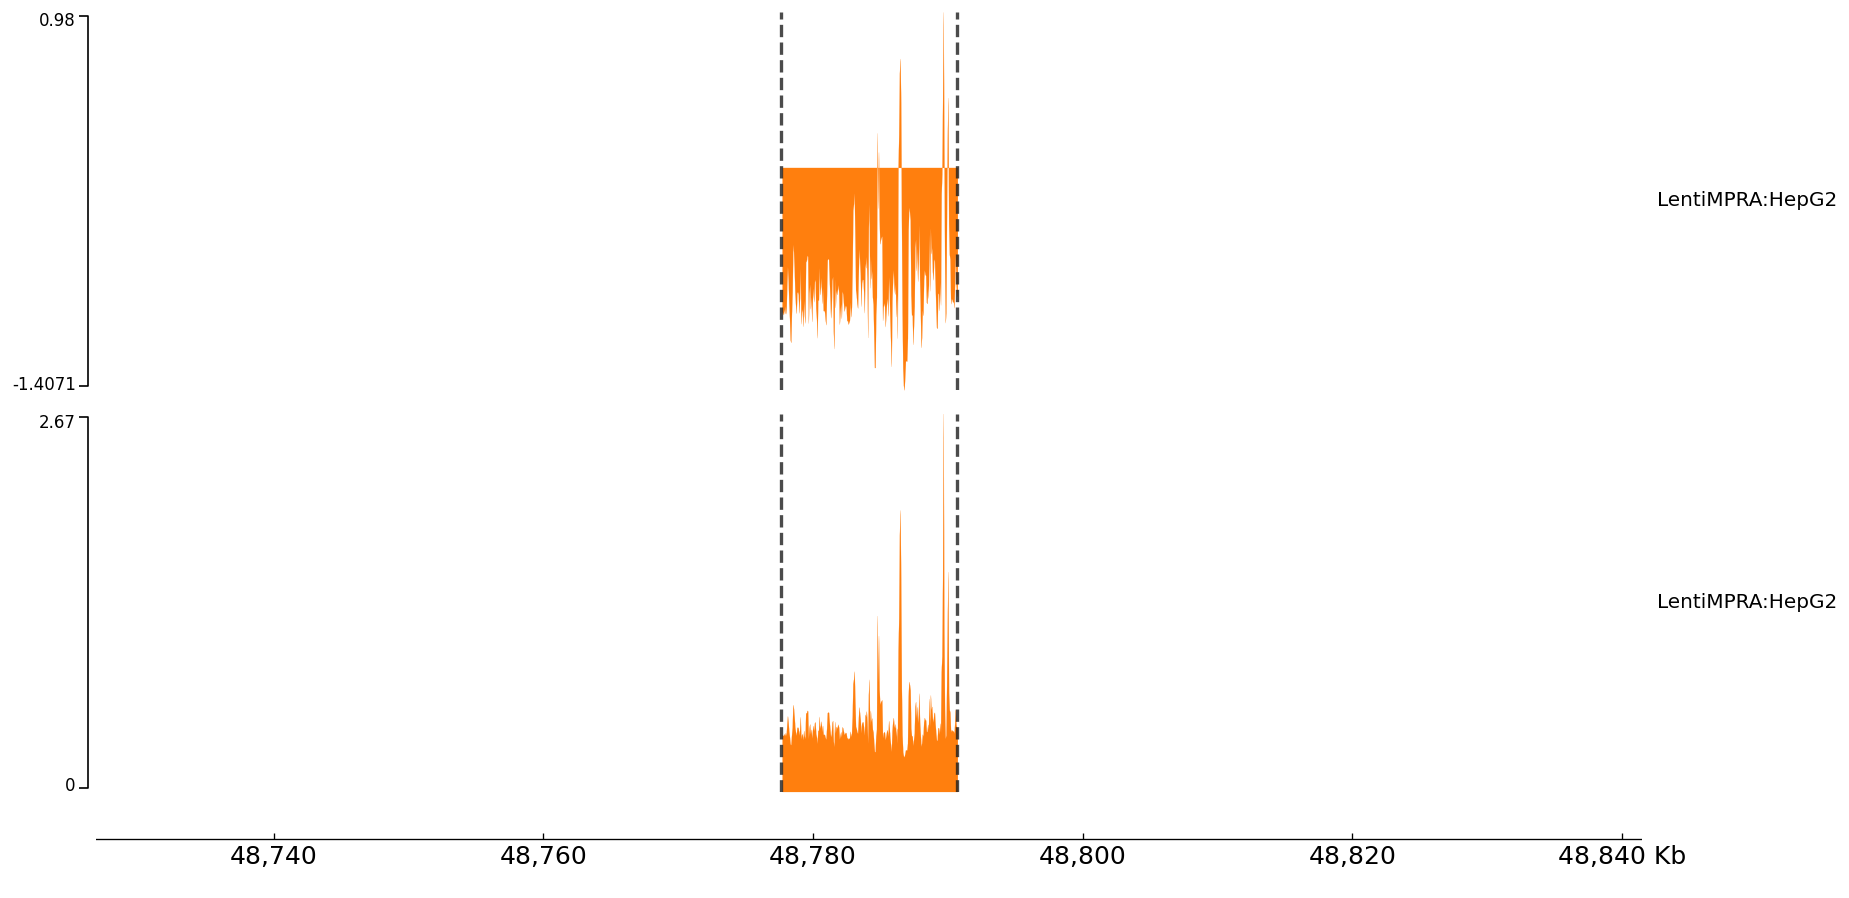

In [14]:
# Visualize LegNet — log-scale MPRA predictions
# LegNet outputs in log scale; also show exponentiated values
pred = list(legnet_results.values())[0]
frame_log = pred.get_coolbox_representation(add_xaxis=False)
pred_exp = pred.exp()
frame_exp = pred_exp.get_coolbox_representation()
frame = frame_log + Spacer(0.5) + frame_exp
frame.plot(PLOT_RANGE)

---
## 6. AlphaGenome — JAX, 1 Mb context, single bp resolution

AlphaGenome (Google DeepMind, Nature 2026) is the latest and most comprehensive genomics model. It predicts 5,930 tracks across 11 modalities at single base-pair resolution from up to 1 Mb of DNA sequence.

In [15]:
# AlphaGenome: explore available tracks
from chorus.oracles.alphagenome_source.alphagenome_metadata import get_metadata
ag_meta = get_metadata()
print(f"AlphaGenome total tracks: {len(ag_meta._track_index_map)}")
print(f"Assay types: {ag_meta.list_assay_types()}")

# Search for ATAC tracks
ag_atac = ag_meta.search_tracks("ATAC")
print(f"\nATAC tracks: {len(ag_atac)}")
if len(ag_atac) > 0:
    print("First 5:")
    for _, row in ag_atac.head(5).iterrows():
        print(f"  {row['identifier']}: {row['description']}")

2026-03-13 07:45:35,432 - chorus.oracles.alphagenome_source.alphagenome_metadata - INFO - Loaded 5731 AlphaGenome tracks


AlphaGenome total tracks: 5731
Assay types: ['ATAC', 'CAGE', 'CHIP', 'DNASE', 'PRO_CAP', 'RNA', 'SPLICE_SITES']

ATAC tracks: 256
First 5:
  ATAC/CL:0000084 ATAC-seq/.: ATAC:T-cell
  ATAC/CL:0000100 ATAC-seq/.: ATAC:motor neuron
  ATAC/CL:0000236 ATAC-seq/.: ATAC:B cell
  ATAC/CL:0000623 ATAC-seq/.: ATAC:natural killer cell
  ATAC/CL:0000624 ATAC-seq/.: ATAC:CD4-positive, alpha-beta T cell


In [16]:
# AlphaGenome: predict with first available ATAC track
ag_track_ids = [ag_atac.iloc[0]['identifier']] if len(ag_atac) > 0 else list(ag_meta._track_index_map.keys())[:1]
print(f"Using track: {ag_track_ids}")

alphagenome_oracle, alphagenome_results = load_and_predict('alphagenome', ag_track_ids)

2026-03-13 07:45:35,439 - chorus.core.base - INFO - Device: auto-detect (GPU if available, else CPU)


2026-03-13 07:45:35,440 - chorus.core.environment.manager - INFO - Found conda via CONDA_EXE: /Users/lp698/miniforge3/bin/conda


2026-03-13 07:45:35,440 - chorus.core.environment.manager - INFO - Found mamba at: /Users/lp698/miniforge3/bin/mamba


2026-03-13 07:45:35,440 - chorus.core.platform - INFO - Detected platform: Darwin arm64 (key=macos_arm64, cuda=False)


Using track: ['ATAC/CL:0000084 ATAC-seq/.']

  ALPHAGENOME


2026-03-13 07:45:36,526 - chorus.core.base - INFO - Using conda environment: chorus-alphagenome


2026-03-13 07:45:36,527 - chorus.oracles.alphagenome - INFO - Loading AlphaGenome model


2026-03-13 07:46:53,975 - chorus.oracles.alphagenome - INFO - AlphaGenome model loaded successfully in environment!


  Loaded. Making prediction with 1 tracks...


    ATAC/CL:0000084 ATAC-seq/.: shape=(1048576,), mean=0.1267, max=204.0000


[ERROR:tab.py:549 - get_indexed_tab_reader()] bgzip is not installed.


2026-03-13 07:49:15,170 - coolbox.utilities.reader.tab - ERROR - bgzip is not installed.


[WARNING:tab.py:550 - get_indexed_tab_reader()] Try to use TabFileReaderInMemory instead


2026-03-13 07:49:15,171 - coolbox.utilities.reader.tab - WARNING - Try to use TabFileReaderInMemory instead


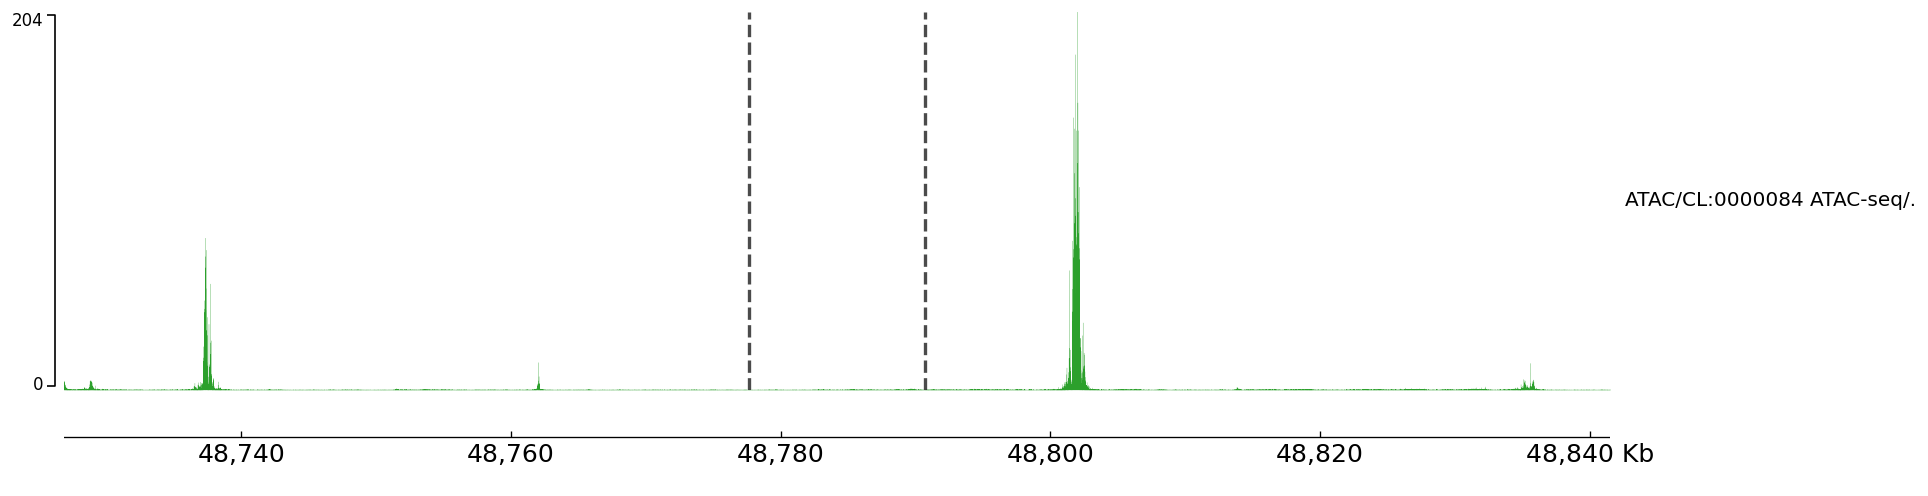

In [17]:
# Visualize AlphaGenome — single bp resolution
pred = list(alphagenome_results.values())[0]
frame = pred.get_coolbox_representation()
frame.plot(PLOT_RANGE)

---
# Operations Showcase

All operations are demonstrated using Enformer, but they work identically with any oracle.

## Operation 1: Region Replacement

Replace a 200 bp sub-region within the GATA1 locus with a synthetic sequence and compare predictions.

In [18]:
# Region replacement: swap 200bp near GATA1 TSS with a synthetic enhancer-like sequence
replace_region = "chrX:48782929-48783129"
replacement_seq = "CACGTG" * 10 + "GATAAG" * 10 + "ACGT" * 20  # E-box + GATA motifs + filler

print(f"Replacing: {replace_region} (200 bp)")
print(f"With: synthetic enhancer ({len(replacement_seq)} bp)")

replacement_results = enformer_oracle.predict_region_replacement(
    genomic_region=replace_region,
    seq=replacement_seq,
    assay_ids=enformer_tracks,
    genome=str(genome_path)
)

print("\nRaw predictions:")
for tid, track in replacement_results['raw_predictions'].items():
    print(f"  {tid}: mean={np.mean(track.values):.4f}, max={np.max(track.values):.4f}")

print("\nNormalized scores (0-1 relative to wild-type):")
for tid, track in replacement_results['normalized_scores'].items():
    print(f"  {tid}: mean={np.mean(track.values):.4f}")

Replacing: chrX:48782929-48783129 (200 bp)
With: synthetic enhancer (200 bp)



Raw predictions:
  ENCFF413AHU: mean=0.3967, max=21.6454
  CNhs11250: mean=0.4066, max=86.8182

Normalized scores (0-1 relative to wild-type):
  ENCFF413AHU: mean=0.0182
  CNhs11250: mean=0.0047


In [19]:
# Visualize: wild-type vs replacement side by side
wt_preds = list(enformer_results.values())
rep_preds = list(replacement_results['raw_predictions'].values())

frame = None
for i, (wt, rep) in enumerate(zip(wt_preds, rep_preds)):
    is_last = (i == len(wt_preds) - 1)
    wt_frame = wt.get_coolbox_representation(add_xaxis=False, override_params={'color': 'steelblue'})
    rep_frame = rep.get_coolbox_representation(add_xaxis=is_last, override_params={'color': 'tomato'})
    pair = wt_frame + Spacer(0.3) + rep_frame
    if frame is None:
        frame = pair
    else:
        frame = frame + Spacer(0.5) + pair
frame.plot(PLOT_RANGE)
print("Blue = wild-type, Red = after replacement")

[ERROR:tab.py:549 - get_indexed_tab_reader()] bgzip is not installed.


2026-03-13 07:49:35,994 - coolbox.utilities.reader.tab - ERROR - bgzip is not installed.


[WARNING:tab.py:550 - get_indexed_tab_reader()] Try to use TabFileReaderInMemory instead


2026-03-13 07:49:35,995 - coolbox.utilities.reader.tab - WARNING - Try to use TabFileReaderInMemory instead


[ERROR:tab.py:549 - get_indexed_tab_reader()] bgzip is not installed.


...

[ERROR:tab.py:549 - get_indexed_tab_reader()] bgzip is not installed.


2026-03-13 07:49:36,031 - coolbox.utilities.reader.tab - ERROR - bgzip is not installed.


[WARNING:tab.py:550 - get_indexed_tab_reader()] Try to use TabFileReaderInMemory instead


2026-03-13 07:49:36,032 - coolbox.utilities.reader.tab - WARNING - Try to use TabFileReaderInMemory instead


Blue = wild-type, Red = after replacement


## Operation 2: Sequence Insertion

Insert a 200 bp synthetic sequence at a specific genomic position. The surrounding genome is shifted to accommodate the insertion.

In [20]:
# Sequence insertion: insert 200bp enhancer upstream of GATA1 TSS
insertion_pos = "chrX:48781929"
insert_seq = replacement_seq  # same synthetic enhancer

print(f"Inserting at: {insertion_pos}")
print(f"Insert length: {len(insert_seq)} bp")

insertion_results = enformer_oracle.predict_region_insertion_at(
    genomic_position=insertion_pos,
    seq=insert_seq,
    assay_ids=enformer_tracks,
    genome=str(genome_path)
)

print("\nInsertion predictions:")
for tid, track in insertion_results['raw_predictions'].items():
    print(f"  {tid}: mean={np.mean(track.values):.4f}, max={np.max(track.values):.4f}")

Inserting at: chrX:48781929
Insert length: 200 bp



Insertion predictions:
  ENCFF413AHU: mean=0.4433, max=21.4267
  CNhs11250: mean=0.4909, max=101.8298


In [21]:
# Visualize insertion normalized scores
ins_preds = list(insertion_results['normalized_scores'].values())
frame = ins_preds[0].get_coolbox_representation(add_xaxis=(len(ins_preds) == 1), override_params={'color': 'darkorange'})
for p in ins_preds[1:]:
    frame = frame + Spacer(0.5) + p.get_coolbox_representation(add_xaxis=(p is ins_preds[-1]), override_params={'color': 'darkorange'})
frame.plot(PLOT_RANGE)
print("Normalized insertion scores (higher = more changed vs wild-type)")

[ERROR:tab.py:549 - get_indexed_tab_reader()] bgzip is not installed.


2026-03-13 07:49:56,952 - coolbox.utilities.reader.tab - ERROR - bgzip is not installed.


[WARNING:tab.py:550 - get_indexed_tab_reader()] Try to use TabFileReaderInMemory instead


2026-03-13 07:49:56,952 - coolbox.utilities.reader.tab - WARNING - Try to use TabFileReaderInMemory instead


[ERROR:tab.py:549 - get_indexed_tab_reader()] bgzip is not installed.


2026-03-13 07:49:56,965 - coolbox.utilities.reader.tab - ERROR - bgzip is not installed.


[WARNING:tab.py:550 - get_indexed_tab_reader()] Try to use TabFileReaderInMemory instead


2026-03-13 07:49:56,965 - coolbox.utilities.reader.tab - WARNING - Try to use TabFileReaderInMemory instead


Normalized insertion scores (higher = more changed vs wild-type)


## Operation 3: Variant Effect Analysis

Test the effect of single nucleotide variants (SNVs) at a position near the GATA1 TSS. This predicts all four alleles and computes effect sizes relative to the reference.

In [22]:
# Variant effect: test all alleles at a position near GATA1 TSS
variant_pos = 48786129
# Extract single reference base at this position
ref_allele = extract_sequence(f"chrX:{variant_pos}-{variant_pos}", str(genome_path))
if len(ref_allele) > 1:
    ref_allele = ref_allele[0]  # Take first base if region returns >1bp
alt_alleles = [a for a in 'ACGT' if a != ref_allele]
all_alleles = [ref_allele] + alt_alleles

print(f"Variant position: chrX:{variant_pos}")
print(f"Reference allele: {ref_allele}")
print(f"Alternative alleles: {alt_alleles}")

variant_results = enformer_oracle.predict_variant_effect(
    genomic_region=f"chrX:{variant_pos-5000}-{variant_pos+5000}",
    variant_position=f"chrX:{variant_pos}",
    alleles=all_alleles,
    assay_ids=enformer_tracks,
    genome=str(genome_path)
)

print(f"\nVariant info: {variant_results['variant_info']}")
print(f"\nEffect sizes per track:")
for allele_key, effects in variant_results['effect_sizes'].items():
    print(f"  {allele_key}:")
    for tid, effect_arr in effects.items():
        mean_effect = np.mean(effect_arr)
        max_effect = np.max(np.abs(effect_arr))
        print(f"    {tid}: mean_delta={mean_effect:+.6f}, max_abs_delta={max_effect:.6f}")

2026-03-13 07:49:57,012 - chorus.core.base - WARNING - Provided reference allele is not the same as the genome reference


Variant position: chrX:48786129
Reference allele: C
Alternative alleles: ['A', 'G', 'T']



Variant info: {'position': 'chrX:48786129', 'ref': 'C', 'alts': ['A', 'G', 'T']}

Effect sizes per track:
  alt_1:
    ENCFF413AHU: mean_delta=-0.000425, max_abs_delta=0.174492
    CNhs11250: mean_delta=-0.003042, max_abs_delta=0.874763
  alt_2:
    ENCFF413AHU: mean_delta=-0.000954, max_abs_delta=0.161562
    CNhs11250: mean_delta=-0.007233, max_abs_delta=2.714050
  alt_3:
    ENCFF413AHU: mean_delta=-0.001228, max_abs_delta=0.108411
    CNhs11250: mean_delta=-0.005496, max_abs_delta=2.274918


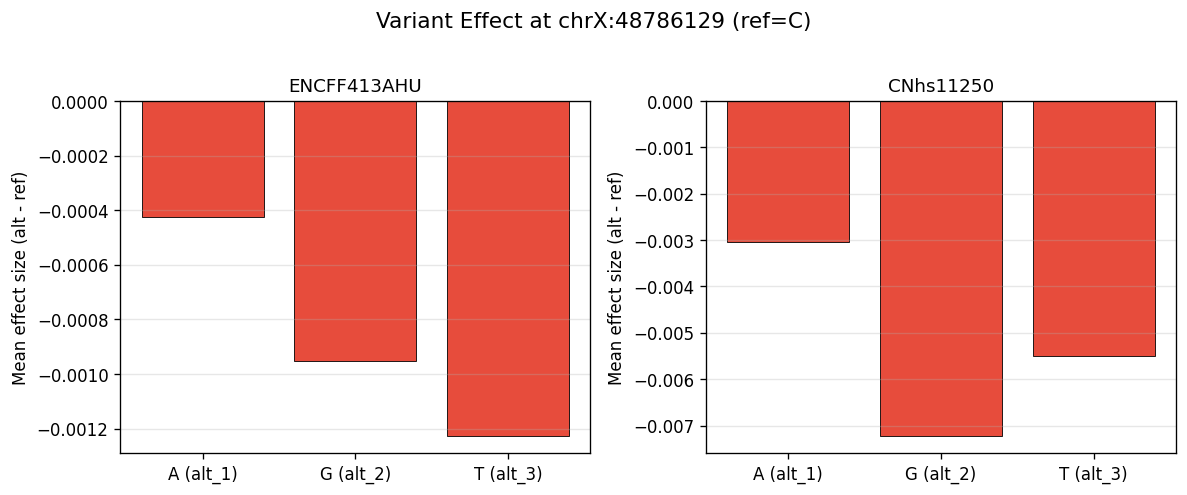

In [23]:
# Visualize variant effects as bar chart
fig, axes = plt.subplots(1, len(enformer_tracks), figsize=(5*len(enformer_tracks), 4))
if len(enformer_tracks) == 1:
    axes = [axes]

for ax, tid in zip(axes, enformer_tracks):
    effects = []
    labels = []
    for allele_key, effect_dict in variant_results['effect_sizes'].items():
        effects.append(float(np.mean(effect_dict[tid])))
        idx = int(allele_key.split("_")[1]) - 1
        labels.append(f"{alt_alleles[idx]} ({allele_key})")
    
    colors = ['#e74c3c' if e < 0 else '#2ecc71' for e in effects]
    ax.bar(labels, effects, color=colors, edgecolor='black', linewidth=0.5)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_title(f'{tid}', fontsize=11)
    ax.set_ylabel('Mean effect size (alt - ref)')
    ax.grid(axis='y', alpha=0.3)

fig.suptitle(f'Variant Effect at chrX:{variant_pos} (ref={ref_allele})', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Operation 4: Sub-Region Scoring

Oracle predictions span the entire output window (e.g. 896 bins × 128 bp = 114 kb for Enformer). Often you care about signal at a **specific peak, promoter, or element** — not the full window.

`score_region()` converts genomic coordinates to bin indices, slices the prediction, and summarises with a scoring strategy (mean, max, sum, or median). It works at any resolution.

In [ ]:
# Score a specific sub-region of the GATA1 prediction
# Define a ~1 kb window around the GATA1 TSS (chrX:48,784,000-48,785,000)
tss_region = ("chrX", 48784000, 48785000)

# Score individual tracks
for tid, track in enformer_results.items():
    for strategy in ['mean', 'max', 'sum', 'median']:
        score = track.score_region(*tss_region, strategy)
        print(f"  {tid} [{strategy:6s}]: {score:.4f}")
    print()

# Score all tracks at once via the OraclePrediction object
print("All tracks scored at once:")
scores = enformer_results.score_region(*tss_region, "mean")
for tid, score in scores.items():
    print(f"  {tid}: {score:.4f}")

In [ ]:
# Compare full-window score vs TSS-focused score
print("Full window vs TSS-focused scoring:")
print(f"{'Track':<20} {'Full window (mean)':>20} {'TSS region (mean)':>20} {'TSS region (max)':>20}")
print("-" * 82)
for tid, track in enformer_results.items():
    full = track.score('mean')
    tss_mean = track.score_region("chrX", 48784000, 48785000, 'mean')
    tss_max = track.score_region("chrX", 48784000, 48785000, 'max')
    print(f"{tid:<20} {full:>20.4f} {tss_mean:>20.4f} {tss_max:>20.4f}")

print("\nThe TSS-focused scores are much higher — the signal is concentrated at the promoter,")
print("while the full-window mean is diluted by low-signal flanking regions.")

## Operation 5: Focused Variant Effect Scoring

`predict_variant_effect()` returns bin-wise differences across the entire output window. `score_variant_effect()` lets you focus on:
- A **specific region** (e.g. a known peak or promoter)
- The **variant site itself** (±N bins around the variant)

This gives more interpretable single-number effect sizes than the full-array summary.

In [ ]:
from chorus.core.result import score_variant_effect

# Mode 1: Score variant effect at the variant site (±2 bins around the variant)
ve_at_variant = score_variant_effect(
    variant_results,
    at_variant=True,
    window_bins=2,
    scoring_strategy='mean'
)

print("Variant effect at the variant site (±2 bins):")
for allele, tracks in ve_at_variant.items():
    print(f"\n  {allele}:")
    for tid, scores in tracks.items():
        print(f"    {tid}: ref={scores['ref_score']:.4f}, alt={scores['alt_score']:.4f}, "
              f"effect={scores['effect']:+.6f}")

In [ ]:
# Mode 2: Score variant effect at the GATA1 TSS region
ve_at_tss = score_variant_effect(
    variant_results,
    chrom="chrX",
    start=48784000,
    end=48785000,
    scoring_strategy='mean'
)

print("Variant effect at GATA1 TSS region (chrX:48784000-48785000):")
for allele, tracks in ve_at_tss.items():
    print(f"\n  {allele}:")
    for tid, scores in tracks.items():
        print(f"    {tid}: ref={scores['ref_score']:.4f}, alt={scores['alt_score']:.4f}, "
              f"effect={scores['effect']:+.6f}")

# Mode 3: abs_max strategy — find the single bin with the largest absolute effect
ve_abs_max = score_variant_effect(
    variant_results,
    chrom="chrX",
    start=48784000,
    end=48785000,
    scoring_strategy='abs_max'
)

print("\nLargest absolute effect in TSS region (abs_max):")
for allele, tracks in ve_abs_max.items():
    for tid, scores in tracks.items():
        print(f"  {allele} / {tid}: peak effect = {scores['effect']:+.6f}")

## Operation 6: Gene Expression Analysis

`oracle.analyze_gene_expression()` quantifies predicted gene expression from a prediction. It auto-detects expression track types and uses the appropriate quantification method:

| Track Type | Method | Rationale |
|-----------|--------|-----------|
| **CAGE** | Max signal in ±N bins around TSS | CAGE peaks sharply at transcription start |
| **RNA-seq** | Sum signal over merged exonic regions | RNA covers the gene body; Borzoi/AlphaGenome papers use exon sum |
| **LentiMPRA** | Same as CAGE (TSS windowed) | Point measurement of reporter activity |

The method auto-detects which tracks are expression-related via `isinstance` checks — it only considers tracks the user already chose via `assay_ids`.

In [ ]:
# First, check what TSS and exon annotations are available for GATA1
from chorus.utils.annotations import get_gene_tss, get_gene_exons

tss_df = get_gene_tss('GATA1')
exon_df = get_gene_exons('GATA1')

print(f"GATA1 transcripts with TSS: {len(tss_df)}")
print(f"Unique TSS positions: {tss_df['tss'].nunique()}")
for _, row in tss_df.drop_duplicates('tss').head(5).iterrows():
    print(f"  {row['chrom']}:{row['tss']} ({row['strand']}) — {row['transcript_id']}")

print(f"\nGATA1 merged exonic regions: {len(exon_df)}")
for _, row in exon_df.head(5).iterrows():
    print(f"  {row['chrom']}:{row['start']}-{row['end']} ({row['end']-row['start']} bp)")

In [ ]:
# Analyze GATA1 expression from the Enformer CAGE prediction
# The method auto-detects that CNhs11250 is a CAGE track and uses TSS windowed max
expr_result = enformer_oracle.analyze_gene_expression(enformer_results, 'GATA1')

print(f"Gene: {expr_result['gene_name']}")
print(f"TSS positions in window: {expr_result['tss_positions'][:5]}")
print(f"Exon regions: {len(expr_result['exon_regions'])} (only fetched if RNA tracks present)")
print(f"\nPer-track expression:")
for tid, info in expr_result['per_track'].items():
    print(f"  {tid}:")
    print(f"    Method:     {info['quantification_method']}")
    print(f"    Expression: {info['expression']:.4f}")
    print(f"    TSS in window: {info.get('n_tss_in_window', 'N/A')}")
    if 'tss_signals' in info:
        print(f"    Per-TSS signals: {[f'{s:.2f}' for s in info['tss_signals'][:5]]}")

## Operation 7: Variant Effect on Gene Expression

The most common question in variant interpretation: **"Does this variant change expression of gene X?"**

`oracle.analyze_variant_effect_on_gene()` combines variant effect prediction with gene expression analysis. It:
1. Quantifies expression from the reference prediction
2. Quantifies expression from each alternate allele prediction
3. Computes fold change, log2 fold change, and absolute change

In [ ]:
# How does the variant at chrX:48786129 affect GATA1 expression?
ve_gene = enformer_oracle.analyze_variant_effect_on_gene(variant_results, 'GATA1')

print(f"Gene: {ve_gene['gene_name']}")
print(f"Variant: {ve_gene['variant_info']['position']} "
      f"{ve_gene['variant_info']['ref']} > {ve_gene['variant_info']['alts']}")
print(f"TSS positions: {ve_gene['tss_positions'][:3]}...")

print(f"\nReference expression:")
for tid, info in ve_gene['reference_expression'].items():
    print(f"  {tid}: {info['expression']:.4f} ({info['quantification_method']})")

print(f"\nVariant effects on GATA1 expression:")
for allele, data in ve_gene['per_allele'].items():
    print(f"\n  {allele}:")
    for tid, vs_ref in data['vs_reference'].items():
        print(f"    {tid}:")
        print(f"      Ref expression:  {vs_ref['ref_expression']:.4f}")
        print(f"      Alt expression:  {vs_ref['alt_expression']:.4f}")
        print(f"      Absolute change: {vs_ref['absolute_change']:+.4f}")
        if vs_ref['fold_change'] is not None:
            print(f"      Fold change:     {vs_ref['fold_change']:.4f}")
        if vs_ref['log2_fold_change'] is not None:
            print(f"      Log2 FC:         {vs_ref['log2_fold_change']:+.4f}")

In [ ]:
# Visualize: fold changes across alleles
fig, ax = plt.subplots(figsize=(8, 4))

# Collect fold changes for the CAGE track
cage_tid = enformer_tracks[1]  # CNhs11250 (CAGE:K562)
allele_labels = []
fold_changes = []

for allele, data in ve_gene['per_allele'].items():
    if cage_tid in data['vs_reference']:
        vs_ref = data['vs_reference'][cage_tid]
        idx = int(allele.split("_")[1]) - 1
        allele_labels.append(f"{alt_alleles[idx]} ({allele})")
        fc = vs_ref['fold_change'] if vs_ref['fold_change'] is not None else 1.0
        fold_changes.append(fc)

colors = ['#e74c3c' if fc < 1 else '#2ecc71' for fc in fold_changes]
bars = ax.bar(allele_labels, fold_changes, color=colors, edgecolor='black', linewidth=0.5)
ax.axhline(1.0, color='black', linewidth=1, linestyle='--', label='No change')
ax.set_ylabel('Fold Change (alt / ref)')
ax.set_title(f'GATA1 Expression Fold Change — {cage_tid} (CAGE)')
ax.grid(axis='y', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

---
## Cross-Oracle Comparison

Compare how different oracles predict the same GATA1 region. Each oracle has different resolution, context window, and track coverage.

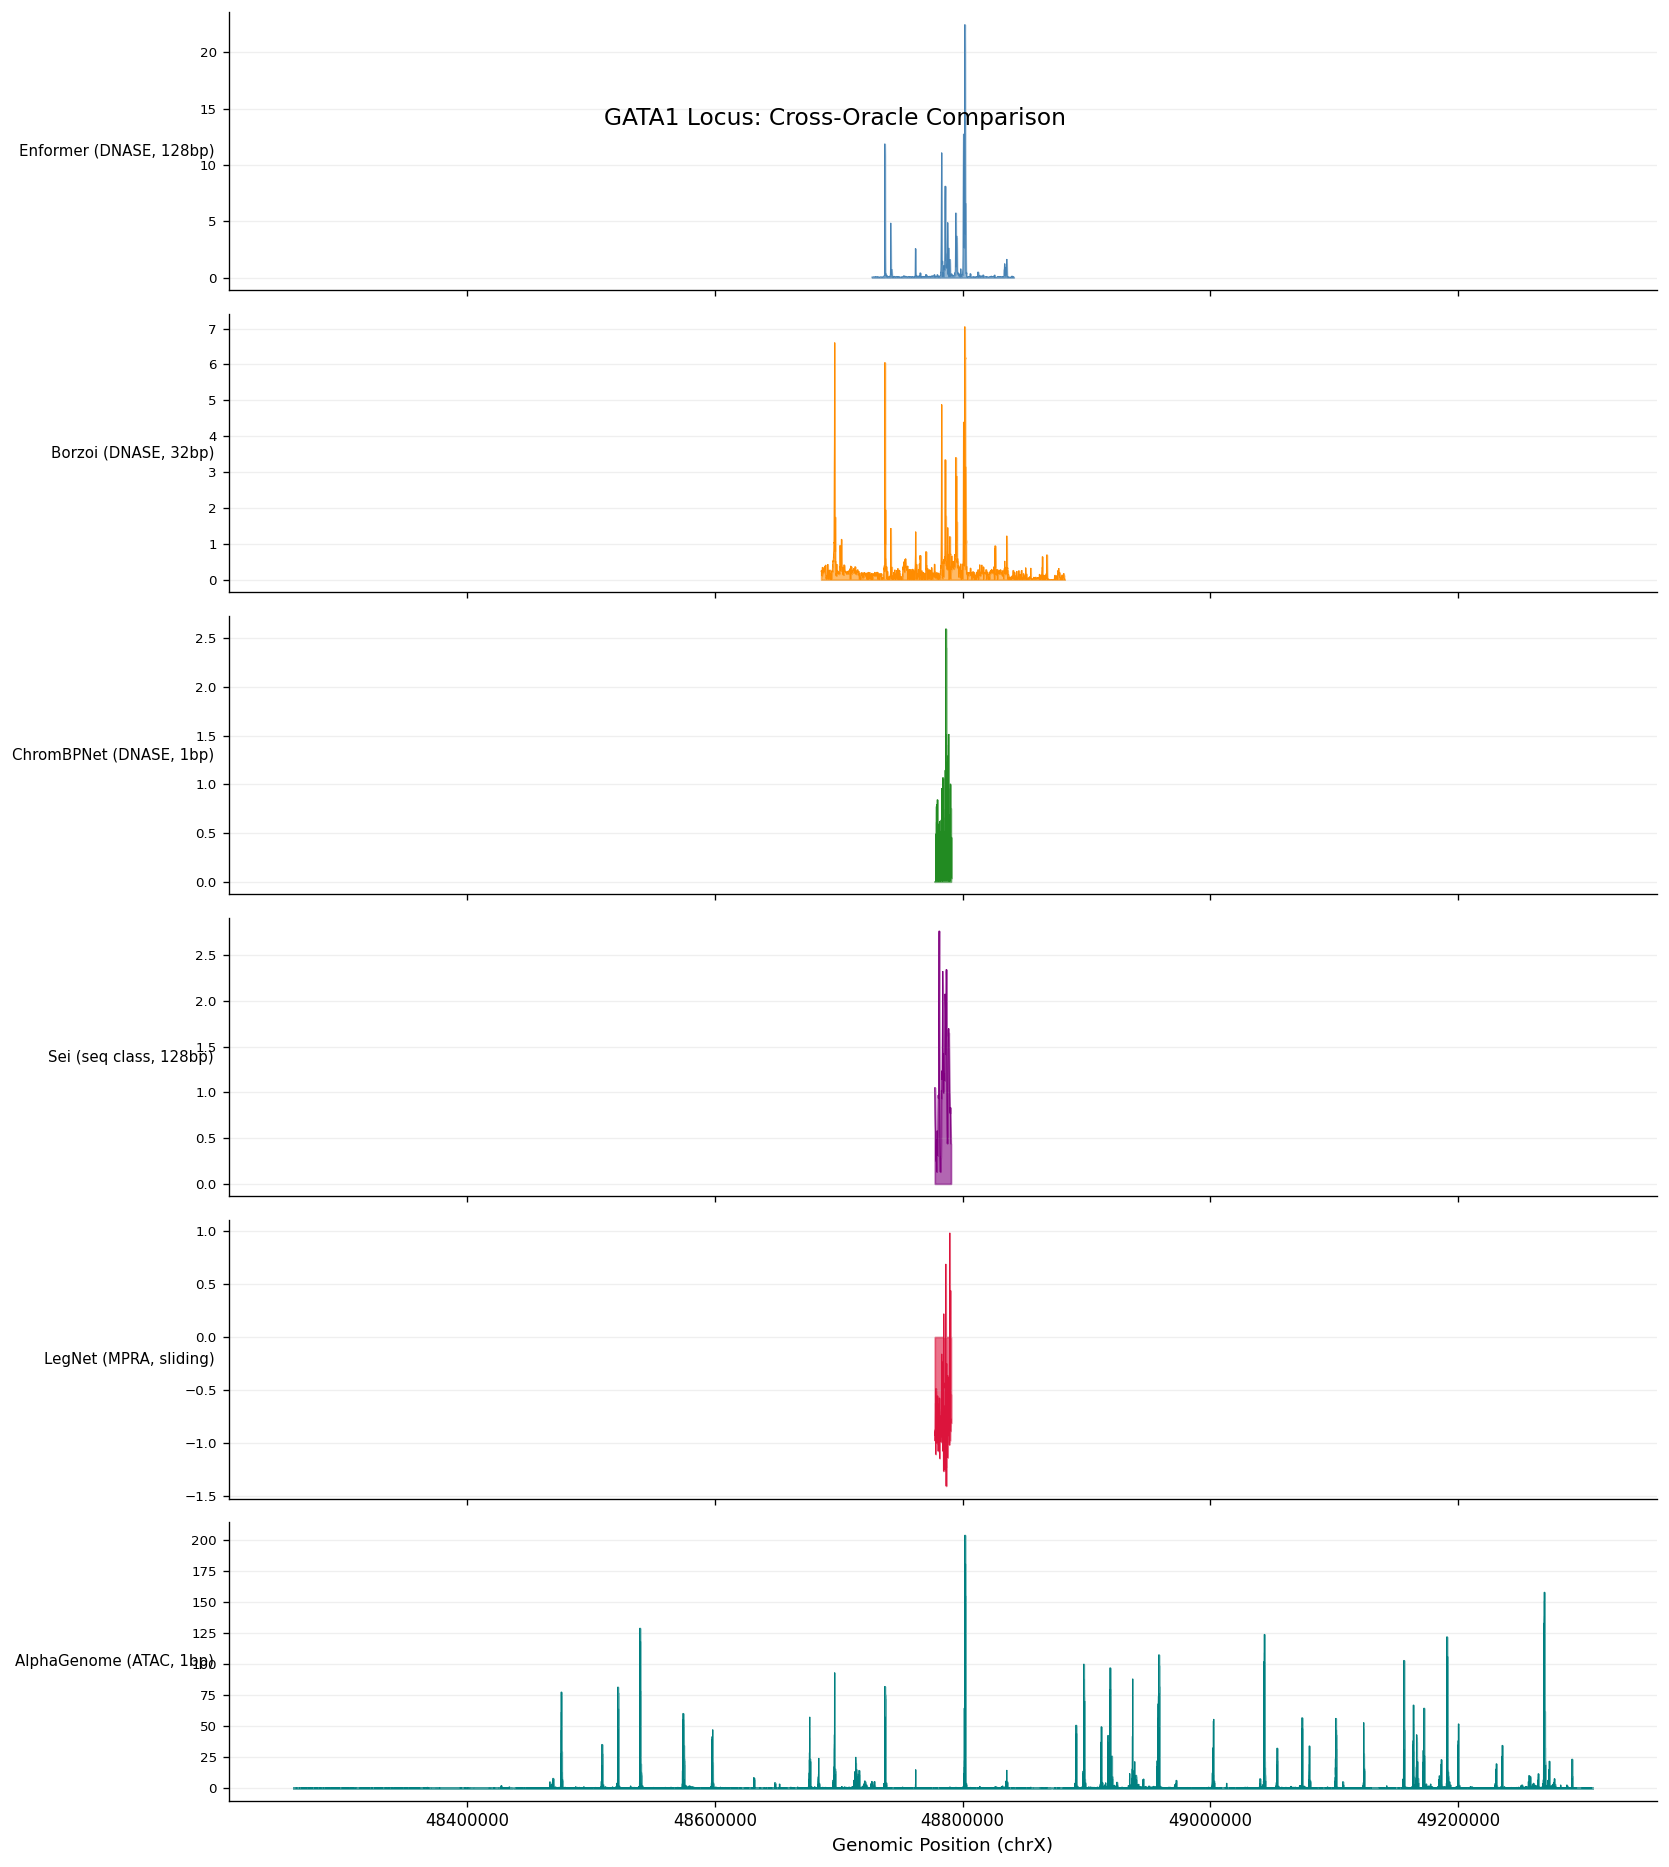

In [24]:
# Cross-oracle comparison: stack all DNASE/chromatin accessibility predictions
# Each oracle predicts the same GATA1 locus but at different resolutions
fig, axes = plt.subplots(6, 1, figsize=(14, 16), sharex=True)

oracle_data = [
    ("Enformer (DNASE, 128bp)", enformer_results, enformer_tracks[0], 'steelblue'),
    ("Borzoi (DNASE, 32bp)", borzoi_results, borzoi_track_ids[0], 'darkorange'),
    ("ChromBPNet (DNASE, 1bp)", chrombpnet_results, chrombpnet_tracks[0], 'forestgreen'),
    ("Sei (seq class, 128bp)", sei_results, sei_track_ids[0], 'purple'),
    ("LegNet (MPRA, sliding)", legnet_results, legnet_tracks[0], 'crimson'),
    ("AlphaGenome (ATAC, 1bp)", alphagenome_results, ag_track_ids[0], 'teal'),
]

for ax, (label, results, tid, color) in zip(axes, oracle_data):
    track = results[tid]
    positions = track.positions
    values = track.values
    
    ax.fill_between(positions, values, alpha=0.6, color=color)
    ax.plot(positions, values, color=color, linewidth=0.5)
    ax.set_ylabel(label, fontsize=9, rotation=0, ha='right', va='center')
    ax.yaxis.set_label_coords(-0.01, 0.5)
    ax.tick_params(axis='y', labelsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.2)

axes[-1].set_xlabel('Genomic Position (chrX)', fontsize=11)
axes[-1].ticklabel_format(style='plain', axis='x')
fig.suptitle('GATA1 Locus: Cross-Oracle Comparison', fontsize=14, y=0.92)
plt.tight_layout()
plt.show()

In [25]:
# Summary table of all oracle predictions
summary_data = []
for label, results, tid, _ in oracle_data:
    track = results[tid]
    summary_data.append({
        'Oracle': label.split('(')[0].strip(),
        'Track': tid[:50],
        'Resolution': f"{track.resolution} bp",
        'Output bins': track.values.shape[0],
        'Mean': f"{np.mean(track.values):.4f}",
        'Max': f"{np.max(track.values):.4f}",
        'Score': f"{track.score():.4f}",
    })

summary_df = pd.DataFrame(summary_data)
print("Oracle Prediction Summary for GATA1 Region")
print("=" * 80)
print(summary_df.to_string(index=False))

Oracle Prediction Summary for GATA1 Region
     Oracle                      Track Resolution  Output bins    Mean      Max   Score
   Enformer                ENCFF413AHU     128 bp          896  0.4842  22.4620  0.4842
     Borzoi                ENCFF899YDP      32 bp         6144  0.2435   7.0530  0.2435
 ChromBPNet                DNASE:HepG2       1 bp        13060  0.1345   2.5971  0.1345
        Sei CA#E1@Stem cell@Enhancer@5     128 bp          103  1.0726   2.7630  1.0726
     LegNet            LentiMPRA:HepG2      50 bp          262 -0.7341   0.9833 -0.7341
AlphaGenome ATAC/CL:0000084 ATAC-seq/.       1 bp      1048576  0.1267 204.0000  0.1267


---
## Summary

This notebook demonstrated the full Chorus oracle system:

| Feature | Demonstrated |
|---------|-------------|
| **6 Oracles** | Enformer, Borzoi, ChromBPNet, Sei, LegNet, AlphaGenome |
| **Wild-type prediction** | `oracle.predict()` on GATA1 region |
| **Region replacement** | `oracle.predict_region_replacement()` with synthetic enhancer |
| **Sequence insertion** | `oracle.predict_region_insertion_at()` at upstream position |
| **Variant effect** | `oracle.predict_variant_effect()` with all 4 alleles |
| **Sub-region scoring** | `prediction.score_region()` — score a specific peak or promoter |
| **Focused variant effect** | `score_variant_effect()` — at variant site or a sub-region |
| **Gene expression** | `oracle.analyze_gene_expression()` — CAGE (TSS max) / RNA (exon sum) |
| **Variant → gene expression** | `oracle.analyze_variant_effect_on_gene()` — fold change at a gene |
| **Track exploration** | `list_assay_types()`, `get_track_info()`, Sei's `select_classes()`/`select_targets()` |
| **Visualization** | CoolBox genome browser tracks, matplotlib comparison plots |
| **Cross-oracle comparison** | Side-by-side predictions at different resolutions |

All oracles use the same API — swap `chorus.create_oracle('enformer')` for any other oracle name and the same operations work transparently.